# Baseline models
#### Previous notebook: [Data provisioning](02_data_provisioning.ipynb)

#### Models implemented in this notebook:
 - [Logistic Regression](#logistic-regression)
 - [Linear SVC](#linear-svc)

## Load train/val/test sets
In this step, I will load the files from the split_data folder to ensure that every model is trained, tuned and evaluated on exactly the same input texts and labels. To load the data, I will use the "load_split_data" function from the `helper.py` file:

In [18]:
from utilities import helper

X_train, X_val, X_test, y_train, y_val, y_test = helper.load_split_data(show = True)
labels = list(y_train.columns)

X_train: (12122,)
X_val: (3742,)
X_test: (3742,)
y_train: (12122, 5)
y_val: (3742, 5)
y_test: (3742, 5)


## Setting TF-IDF
In this step, I create a TF-IDF vectorizer configuration function to create a new vectorizer for each model. The TF-IDF vectorizer is used to measure how important a token is - tokens that are frequent in a message but not that frequent across the whole dataset, will be assigned with higher weights. Before tokenization and weighting, the text message is normalized by the `preprocess_text` function to ensure the consistency of the input format and reduce noise - the text is lowercased; URLs, emails, user mentions, hashtags and numbers are replaced with fixed placeholder tokens; extra white spaces are removed and spaCy lemmatization is applied to reduce the words to their base or dictionary form. After that, the text is tokenized by splitting on white spaces. The *ngram_range* uses both unigrams(single words) and bigrams(pair of 2 words) to capture short phrases, which might carry important information. Lasty, *min_df* and *max_df* are used to exclude very rare and too common tokens in order to reduce noise and improve generalization.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from utilities.text_normalization import preprocess_text

def make_tfidf():
    return TfidfVectorizer(
        preprocessor=preprocess_text,
        tokenizer=str.split,
        token_pattern=None,
        ngram_range=(1, 1),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )

## Get model scores
Different models score their predictions in different ways - some give probabilities in the range 0-1, while others base their decisions on negative and positive scores. In this notebook I implement both types of models, which is why the function below checks which scoring method the model supports and returns the correct score matrix. These scores are later compared to a chosen threshold and converted into the final binary multi-label predictions:

In [20]:
def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores

## Choose best score
In this step, I create a function to select the best threshold for turning the models' scores into final 0/1 predictions. The baseline models do not output direct binary labels - instead they output confidence scores. The function takes the real labels, the confidence scores and a list of thresholds. For each threshold, it converts the confidence scores into 0/1 predictions and calculates the micro F1-score (summarizes performance across all labels). Finally, the function returns the threshold with the highest micro F1-score.

In [21]:
from sklearn.metrics import f1_score

def best_thresholds_per_label_from_scores(y_true, y_scores, thresholds):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores)

    best_t = np.zeros(y_true.shape[1])
    best_f1 = np.zeros(y_true.shape[1])

    for j in range(y_true.shape[1]):
        yj = y_true[:, j]
        sj = y_scores[:, j]

        best_f1_j = -1.0
        best_t_j = thresholds[0]

        for t in thresholds:
            pred = (sj >= t).astype(int)
            f1 = f1_score(yj, pred, zero_division=0)
            if f1 > best_f1_j:
                best_f1_j = f1
                best_t_j = t

        best_t[j] = best_t_j
        best_f1[j] = best_f1_j

    return best_t, best_f1

## General tuning
The purpose of this function is to construct a model, train it, test different hyperparameter values and, for each value, find the best decision threshold, using the previous function (*best_threshold_micro_f1_from_scores*). For each *param_grid* setting, it finds and saves the best threshold and micro F1-score. In the end, the function returns the parameter setting that achieved the highest micro F1-score, as well as a table presenting the results of all tested hyperparameters settings:

In [22]:
import pandas as pd

def general_tuning(X_train, y_train, X_val, y_val,make_pipeline_fn,param_grid,thresholds):
    rows = []

    for params in param_grid:
        model = make_pipeline_fn()
        model.set_params(**params)
        model.fit(X_train, y_train)

        y_scores = get_scores(model, X_val)
        best_t, best_f1_per_label = best_thresholds_per_label_from_scores(y_val, y_scores, thresholds)
        y_pred = (y_scores >= best_t.reshape(1, -1)).astype(int)
        val_micro = f1_score(y_val, y_pred, average="micro", zero_division=0)

        rows.append({
            **params,
            "val_micro_f1": float(val_micro),
            "thresholds_per_label": best_t.tolist(),
            "val_f1_per_label": best_f1_per_label.tolist(),
            "model": model
        })

    best = max(rows, key=lambda r: r["val_micro_f1"])
    return best, pd.DataFrame([{k: v for k, v in r.items() if k != "model"} for r in rows])

## Evaluation
The purpose of the *evalute_model* function is to evaluate an already trained model. First, it gets the model's confidence scores and uses the selected threshold to convert them into binary predictions. After that it calculates the model's micro and macro F1-score, the Hamming loss and the micro Jaccard score, and saves them along with the model's name and threshold. Finally, it returns the results with the predicted labels:

In [23]:
from sklearn.metrics import hamming_loss, jaccard_score

def evaluate_model(model, X, y, thresholds_per_label, model_name):
    y_scores = get_scores(model, X)
    thr = np.asarray(thresholds_per_label, dtype=float)
    y_pred = (y_scores >= thr.reshape(1, -1)).astype(int)

    metrics_row = {
        "model": model_name,
        "thresholds_per_label": thr.tolist(),
        "micro_f1": float(f1_score(y, y_pred, average="micro", zero_division=0)),
        "macro_f1": float(f1_score(y, y_pred, average="macro", zero_division=0)),
        "hamming_loss": float(hamming_loss(y, y_pred)),
        "jaccard_micro": float(jaccard_score(y, y_pred, average="micro", zero_division=0)),
    }

    return metrics_row, y_pred

The evaluation metrics used in this project are specifically chosen for proper multi-label classification evaluation:
 - **Micro F1-score** - shows the overall performance of a model across all labels; works well with imbalanced dataset; could hide poor performance on rare labels
 - **Macro F1-score** - calculates the F1-score for all labels and averages the results, gives equal importance to each label, useful to show how a model performs on rare labels
 - **Hamming loss** - shows the fraction of incorrectly predicted labels, lower results show better performance
 - **Jaccard similarity** - measures the overlap between true and predicted labels, strict - predicting extra labels or missing true labels reduces the score, higher results show better performance

# Modeling
## Logistic Regression
In this step, I will create a function that returns a new unfitted model on each run, which makes hyperparameter tuning easier. First, I create a pipeline to ensure no data leakage is introduced. The first step in the pipeline is the TF-IDF vectorizer, which converts each input message into numerical features and ensures text normalization and consistency. Then, the model is wrapped into "OneVsRestClassifier", which is very important for multi-label classification problems - creates and trains separate Logistic Regression per label and combines the outputs for the final prediction. The hyperparameter C is used to control th regularization of the model - smaller values apply stronger regularization, bigger values allow the model to fit more closely on the data. The *class_weight* is set to balanced to help the model handle label imbalance - gives more weight to the minority class during training.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline

def make_lr_pipe():
    return Pipeline([
    ("tfidf", make_tfidf()),
    ("clf", OneVsRestClassifier(LogisticRegression(max_iter=2000, class_weight="balanced")))
])

### Tuning model
In this step, I will use the *general_tuning* function to tune the Logistic Regression and find the threshold that gives the highest micro F1-score on the validation set. The *C_grid* list consists of smaller and larger numbers close to the default value to test different regularization strengths.

In [25]:
import numpy as np
from sklearn.model_selection import ParameterGrid

param_grid = list(ParameterGrid({
    "clf__estimator__C": [0.5, 1.0, 2.0],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2],
    "tfidf__max_df": [0.9, 0.95],
    "tfidf__sublinear_tf": [True, False],
}))
thresholds = np.arange(0.2, 0.81, 0.05)
best_lr, lr_results = general_tuning(X_train, y_train, X_val, y_val,make_pipeline_fn=make_lr_pipe,param_grid=param_grid,thresholds=thresholds)

print("Best LR params:", {k: best_lr[k] for k in best_lr if k not in ["model"]})
display(lr_results.sort_values("val_micro_f1", ascending=False).head(10))

KeyboardInterrupt: 

The tuning results show that the model scored the highest micro F1-score (0.62) with regularization strength of 2.0 and threshold of nearly 0.55. This suggests that the model performs best on this multi-label classification task with slightly weaker regularization and a threshold just above the default 0.5, which helps balance precision and recall.

### Evaluation
In this step, I will evaluate the performance of the best model using the evaluate function explained in the beginning of the notebook. After that, I will print a classification report to visualise the perfomance of the model on each label separately:

In [17]:
from sklearn.metrics import classification_report

results, y_test_pred = evaluate_model( best_lr["model"], X_test, y_test, best_lr["thresholds_per_label"], "Logistic Regression")
lr_df = pd.DataFrame([results]).round(2)
lr_df.to_csv("../data/results/logistic_regression_results.csv", index=False)
display(lr_df)
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=labels, zero_division=0))

,model,threshold,micro_f1,macro_f1,hamming_loss,jaccard_micro
0,Logistic Regression,0.65,0.61,0.59,0.08,0.44


Classification report:
                     precision    recall  f1-score   support

need_basic_supplies       0.73      0.74      0.73       576
  need_medical_help       0.56      0.53      0.55       433
 need_safety_rescue       0.45      0.44      0.44       269
       need_shelter       0.66      0.69      0.68       355
      people_status       0.55      0.53      0.54       295

          micro avg       0.61      0.61      0.61      1928
          macro avg       0.59      0.59      0.59      1928
       weighted avg       0.61      0.61      0.61      1928
        samples avg       0.23      0.22      0.22      1928



The results above show that the Logistic regression model achieves micro F1-score of 0.61, macro F1 - 0.58, hamming loss of 0.08 and Jaccard = 0.44. The small difference between the micro and macro F1-scores, suggests that the model performs slightly better with more common labels rather than the rare ones. The Hamming loss result shows that most label decisions are correct - lower incorrectly predicted label fraction. The Jaccard score shows moderate prediction between the true and predicted labels, probably because the model often predicts some correct labels per message but does not always match the full set perfectly. The classification report shows that the model performance best for the "need_basic_supplies" and struggles mostly with the "need_safety_rescue" label, which is probably due to the label imbalance and the fact that some words or phrases can overlap per label, making it harder to distinguish them.

## Linear SVC
Similarly to the previous model, in this step I will create a function that returns a new unfitted Linear SVC on each run. First in the pipeline is the TF-IDF vectorizer, which is used to apply the same text preprocessing and convert the input message into numerical features. Then, the model is wrapped in "OneVsRestClassifier" to create a linear SVC for each label and then combine all predictions in one. I assign the *class_weight* again to balanced to reduce the impact of label imbalance.

In [24]:
from sklearn.svm import LinearSVC

def make_svc_pipe():
    return Pipeline([
        ("tfidf", make_tfidf()),
        ("clf", OneVsRestClassifier(LinearSVC(class_weight="balanced", max_iter=2000)))
    ])

#### Tuning model
In this step, I will tune the linear SVC model similarly to the previous one. The difference here is that the model provides decision scores instead of probabilities. To create the threshold grid, I create 25 evenly placed points between the 5th and the 95th percentiles. Next, I use the *general_tuning* function to store and find the hyperparameter value and threshold that has the highest micro F1-score:

In [25]:
svm_probe = make_svc_pipe(C=1.0)
svm_probe.fit(X_train, y_train)

val_scores = get_scores(svm_probe, X_val)
thresholds_svm = np.percentile(val_scores, np.linspace(5, 95, 25))
C_grid = [0.25, 0.5, 1.0, 2.0, 4.0]
param_grid = [{"C": C} for C in C_grid]

best_svm, svm_results = general_tuning(X_train, y_train, X_val, y_val,make_pipeline_fn=make_svc_pipe,param_grid=param_grid,thresholds=thresholds_svm)

print("Best SVC params:", {k: best_svm[k] for k in best_svm if k not in ["model"]})
display(svm_results.sort_values("val_micro_f1", ascending=False).head(10))

Best SVC params: {'C': 0.25, 'threshold': 0.07661697151655834, 'val_micro_f1': 0.618890858445176}


,C,threshold,val_micro_f1
0,0.25,0.076617,0.618891
1,0.50,0.076617,0.607454
2,1.00,0.076617,0.594298
3,2.00,0.076617,0.584676
4,4.00,-0.163796,0.579273


As we can see from above, the model score the highest micro F1-score with smaller regularization and a threshold of approximately 0.078. The results show that this model needs stronger regularization to perform better. Additionally, the threshold value looks small, just because the model does not output probabilities.

#### Evaluation
In this step, I will evaluate the performance of the best model using the evaluate function explained in the beginning of the notebook. After that, I will print a classification report to visualise the perfomance of the model on each label separately:

In [26]:
from sklearn.metrics import classification_report

results, y_test_pred = evaluate_model(best_svm["model"], X_test, y_test, best_svm["thresholds_per_label"],"LinearSVC")

svm_df = pd.DataFrame([results]).round(2)
svm_df.to_csv("../data/results/linear_svc_results.csv", index=False)

display(svm_df)
print("Classification report:")
print(classification_report(y_test, y_test_pred, target_names=labels, zero_division=0))

,model,threshold,micro_f1,macro_f1,hamming_loss,jaccard_micro
0,LinearSVC,0.08,0.61,0.58,0.08,0.44


Classification report:
                     precision    recall  f1-score   support

need_basic_supplies       0.74      0.77      0.76       593
  need_medical_help       0.49      0.54      0.52       416
 need_safety_rescue       0.43      0.44      0.43       243
       need_shelter       0.62      0.67      0.65       344
      people_status       0.52      0.57      0.54       292

          micro avg       0.59      0.63      0.61      1888
          macro avg       0.56      0.60      0.58      1888
       weighted avg       0.59      0.63      0.61      1888
        samples avg       0.21      0.22      0.21      1888



Overall, the results above show that the model achieved micro F1 score of 0.61, macro F1-score of 0.58, Hamming loss of 0.08 and Jaccard score of 0.44. Similarly to the previous model, the Linear SVC performs better with more common labels. The Hamming loss and the Jaccard score are exactly the same as for the previous model. From the classification report, I can see that the SVC performs well with the "need_basic_supplies" and struggles with the "need_safety_rescue" label.

# Model comparison

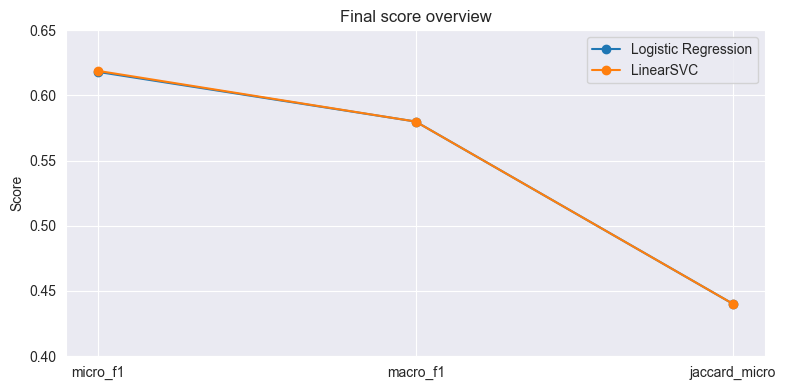

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

lr  = pd.read_csv("../data/results/logistic_regression_results.csv")
svc = pd.read_csv("../data/results/linear_svc_results.csv")
df = pd.concat([lr, svc], ignore_index=True)
score_df = df.copy()
melt = score_df.melt( id_vars=["model"],value_vars=["micro_f1", "macro_f1", "jaccard_micro"], var_name="metric",value_name="score")

plt.figure(figsize=(8,4))
for model in melt["model"].unique():
    sub = melt[melt["model"] == model]
    plt.plot(sub["metric"], sub["score"], marker="o", label=model)

plt.ylim(0.40, 0.65)
plt.ylabel("Score")
plt.title("Final score overview")
plt.legend()
plt.tight_layout()
plt.show()

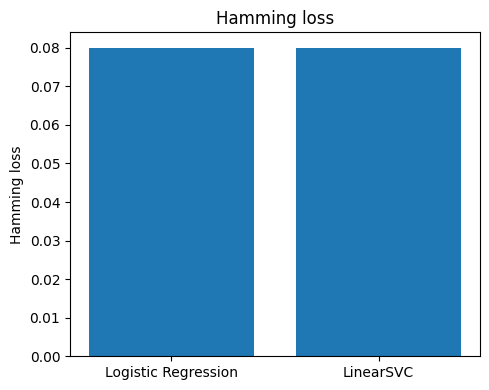

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.bar(df["model"], df["hamming_loss"])
plt.title("Hamming loss")
plt.ylabel("Hamming loss")
plt.tight_layout()
plt.show()

Overall, the Logistic Regression and the Linear SVC achieved similar performance. The "Final score overview" and "Hamming loss" show that they share the same micro and macro F1, Jaccard and Hamming results.  The moderate Jaccard score shows that both models manage to predict some of the labels but struggle to match perfectly the full set.

## Inference testing

In [37]:
import pandas as pd
import numpy as np

df_inf = pd.read_csv("../data/final/disaster_inference.csv")
texts = df_inf["message"].astype(str).tolist()
idxs = [5, 48]
y_true = df_inf[labels].values

lr_model, lr_t   = best_lr["model"], best_lr["threshold"]
svc_model, svc_t = best_svm["model"], best_svm["threshold"]
sel_texts = [texts[i] for i in idxs]

lr_scores = lr_model.predict_proba(sel_texts)
lr_pred   = (lr_scores >= lr_t).astype(int)

svc_scores = svc_model.decision_function(sel_texts)
svc_pred   = (svc_scores >= svc_t).astype(int)

for k, i in enumerate([5,48]):
    msg = texts[i]

    true_labels = [labels[j] for j in np.where(y_true[i] == 1)[0]]
    lr_labels   = [labels[j] for j in np.where(lr_pred[k] == 1)[0]]
    svc_labels  = [labels[j] for j in np.where(svc_pred[k] == 1)[0]]

    print("\nMESSAGE:", msg[:350].replace("\n", " "))
    print("True labels        :", true_labels)
    print("LR predicted labels :", lr_labels)
    print("SVC predicted labels:", svc_labels)


MESSAGE: People had been predicting earthquakes, tidal waves and we even felt a few tremors recently, but obviously we did not take the warnings seriously.
True labels        : []
LR predicted labels : []
SVC predicted labels: []

MESSAGE: ( No location ) We have no water and food, we have no tent, and the children are starting to be sick.
True labels        : ['need_basic_supplies', 'need_medical_help', 'need_shelter']
LR predicted labels : ['need_basic_supplies', 'need_medical_help', 'need_shelter']
SVC predicted labels: ['need_basic_supplies', 'need_medical_help', 'need_shelter']
